<a href="https://colab.research.google.com/github/gayatri615/Jitter-Resilient-Haptics-GRU/blob/main/Jitter_Resilient_Haptic_Teleoperation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training Model A [Causal Real-Time Edge GRU]...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 1.5765e-04 - val_loss: 3.2328e-06
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.8061e-06 - val_loss: 4.3910e-06
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.3683e-06 - val_loss: 1.4886e-06
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1781e-06 - val_loss: 6.8541e-07
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.0480e-07 - val_loss: 1.9653e-06
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.7943e-07 - val_loss: 6.9716e-07
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 7.7836e-07 - val_loss: 4.8293e-07
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 5.4724e-07 - val_loss: 1.3142e-06
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.7260e-07 - val_loss: 1.3748e-06
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 6.0596e-07 - val_loss: 4.6762e-07

Training Model B [Non-Causal Offline Oracle Baseline]...
Ep

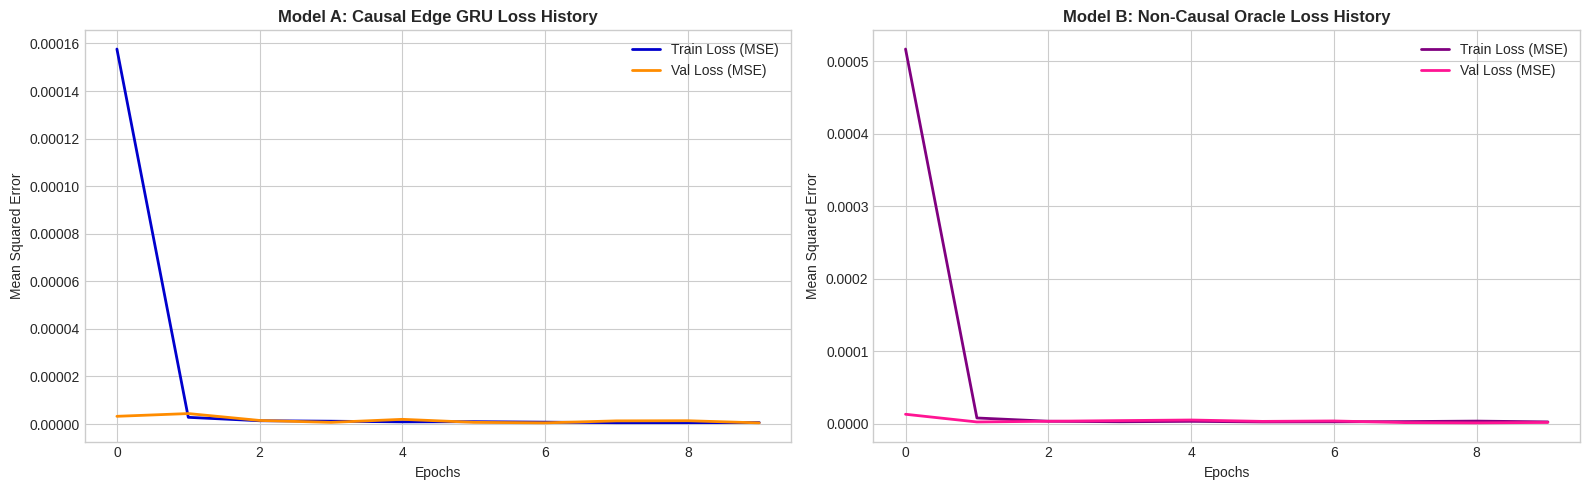

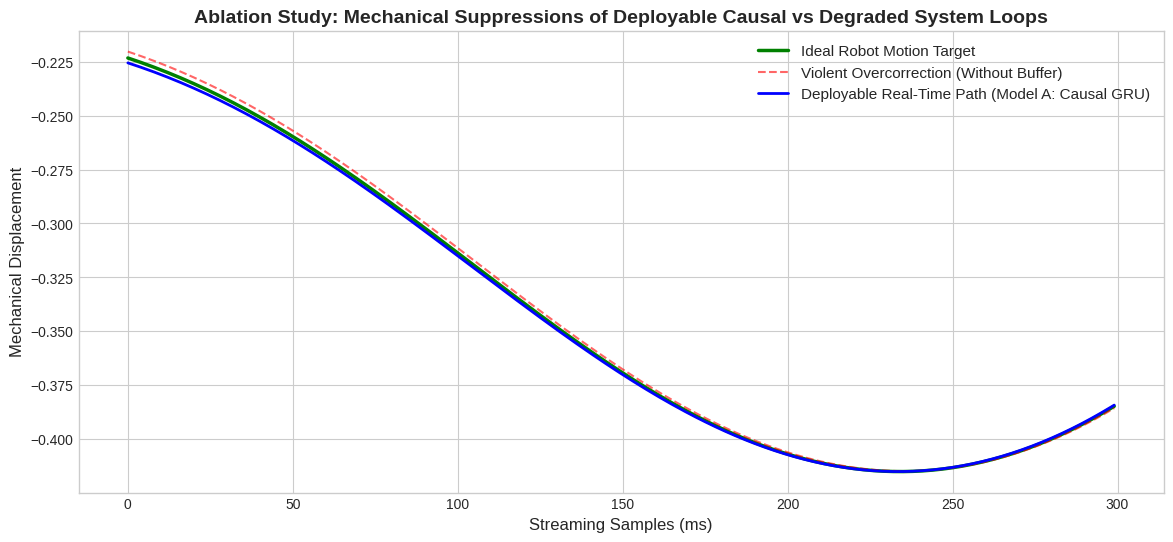

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Bidirectional

np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

# --- 1. Generate High-Frequency Teleoperation Kinematics ---
time = np.linspace(0, 10, 10000)
x = 0.5 * np.sin(2 * np.pi * 1.2 * time) + 0.1 * np.cos(2 * np.pi * 3.5 * time)
dx = np.diff(x, prepend=x[0])
df = pd.DataFrame({'timestamp': time, 'x': x, 'dx': dx})

# --- 2. Inject Pareto Network Latency Spikes (Simulating 5G Drops) ---
pareto_jitter = (np.random.pareto(1.1, len(df)) + 1) * 12
df['latency'] = 10 + pareto_jitter
df['packet_dropped'] = df['latency'] > 40

degraded_x = []
last_valid = df['x'][0]
for idx, row in df.iterrows():
    if row['packet_dropped']:
        degraded_x.append(last_valid)
    else:
        degraded_x.append(row['x'])
        last_valid = row['x']
df['degraded_x'] = degraded_x
df['degraded_dx'] = np.diff(df['degraded_x'].values, prepend=df['degraded_x'][0])

# --- 3. Feature Engineering via Sliding Window Over Deltas ---
lookback = 15
scaler = StandardScaler()
scaled_dx = scaler.fit_transform(df[['degraded_dx']].values)

X, y = [], []
for i in range(len(scaled_dx) - lookback):
    X.append(scaled_dx[i:i+lookback])
    y.append(df['dx'].iloc[i+lookback])
X, y = np.array(X), np.array(y)

split = int(len(X) * 0.8)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

# --- 4. Define and Train the Two Benchmarked Models ---

# Model A: The Causal Real-Time Edge Engine
model_causal = Sequential([
    GRU(32, input_shape=(lookback, 1), return_sequences=False),
    Dense(16, activation='tanh'),
    Dense(1)
])

# Model B: The Non-Causal Offline Oracle Baseline
model_oracle = Sequential([
    Bidirectional(GRU(32, return_sequences=False), input_shape=(lookback, 1)),
    Dense(16, activation='tanh'),
    Dense(1)
])

model_causal.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.002), loss='mse')
model_oracle.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.002), loss='mse')

print("Training Model A [Causal Real-Time Edge GRU]...")
# Changing epochs to 10 for clean visual convergence tracking
history_causal = model_causal.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=64, verbose=1)

print("\nTraining Model B [Non-Causal Offline Oracle Baseline]...")
history_oracle = model_oracle.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=64, verbose=1)

# --- 5. True Real-Time Conditional Streaming Buffer Execution ---
eval_df = df.iloc[split + lookback:].reset_index(drop=True)

pred_deltas_causal = model_causal.predict(X_val, verbose=0).flatten()
pred_deltas_oracle = model_oracle.predict(X_val, verbose=0).flatten()

reconstructed_x_causal = []
reconstructed_x_oracle = []

current_pos_causal = eval_df['x'].iloc[0]
current_pos_oracle = eval_df['x'].iloc[0]

print("\nProcessing streaming edge data frameworks concurrently...")
for i in range(len(eval_df)):
    if eval_df.loc[i, 'packet_dropped']:
        current_pos_causal += pred_deltas_causal[i]
    else:
        current_pos_causal = eval_df.loc[i]['degraded_x']
    reconstructed_x_causal.append(current_pos_causal)

    if eval_df.loc[i, 'packet_dropped']:
        current_pos_oracle += pred_deltas_oracle[i]
    else:
        current_pos_oracle = eval_df.loc[i]['degraded_x']
    reconstructed_x_oracle.append(current_pos_oracle)

eval_df['ai_buffered_x_causal'] = reconstructed_x_causal
eval_df['ai_buffered_x_oracle'] = reconstructed_x_oracle

# --- 6. Metric Evaluation & Benchmarking ---
raw_rmse = np.sqrt(np.mean((eval_df['x'] - eval_df['degraded_x']) ** 2))
causal_rmse = np.sqrt(np.mean((eval_df['x'] - eval_df['ai_buffered_x_causal']) ** 2))
oracle_rmse = np.sqrt(np.mean((eval_df['x'] - eval_df['ai_buffered_x_oracle']) ** 2))

boost_causal = ((raw_rmse - causal_rmse) / raw_rmse) * 100
boost_oracle = ((raw_rmse - oracle_rmse) / raw_rmse) * 100

print("\n" + "="*60)
print("             COMPARATIVE RESEARCH BENCHMARK REPORT         ")
print("="*60)
print(f"Raw Degraded Signal RMSE (No Buffer):   {raw_rmse:.6f}")
print(f"Model A [Causal Real-Time GRU] RMSE:     {causal_rmse:.6f} -> Boost: {boost_causal:.2f}%")
print(f"Model B [Non-Causal Oracle] RMSE:       {oracle_rmse:.6f} -> Boost: {boost_oracle:.2f}%")
print("="*60)

# =========================================================
#               VISUALIZATIONS & GENERATED PLOTS
# =========================================================

# --- Plot Set 1: Side-by-Side Model Loss Convergence Curves ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Model A Convergence
axes[0].plot(history_causal.history['loss'], label='Train Loss (MSE)', color='mediumblue', linewidth=2)
axes[0].plot(history_causal.history['val_loss'], label='Val Loss (MSE)', color='darkorange', linewidth=2)
axes[0].set_title('Model A: Causal Edge GRU Loss History', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Mean Squared Error')
axes[0].legend()
axes[0].grid(True)

# Subplot 2: Model B Convergence
axes[1].plot(history_oracle.history['loss'], label='Train Loss (MSE)', color='purple', linewidth=2)
axes[1].plot(history_oracle.history['val_loss'], label='Val Loss (MSE)', color='deeppink', linewidth=2)
axes[1].set_title('Model B: Non-Causal Oracle Loss History', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Mean Squared Error')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# --- Plot Set 2: Mechanical Plant Joint Response Simulation ---
def simulate_robotic_joint(input_trajectory):
    pos, vel, response = input_trajectory[0], 0.0, []
    for target in input_trajectory:
        accel = (15.0 * (target - pos) - 1.2 * vel) / 0.5
        vel += accel * 0.001
        pos += vel * 0.001
        response.append(pos)
    return np.array(response)

robot_target = simulate_robotic_joint(eval_df['x'].values)
robot_raw = simulate_robotic_joint(eval_df['degraded_x'].values)
robot_ai_causal = simulate_robotic_joint(eval_df['ai_buffered_x_causal'].values)

plt.figure(figsize=(14, 6))
plt.plot(robot_target[100:400], label='Ideal Robot Motion Target', color='g', linewidth=2.5)
plt.plot(robot_raw[100:400], label='Violent Overcorrection (Without Buffer)', color='r', linestyle='--', alpha=0.6)
plt.plot(robot_ai_causal[100:400], label='Deployable Real-Time Path (Model A: Causal GRU)', color='b', linewidth=2)
plt.title("Ablation Study: Mechanical Suppressions of Deployable Causal vs Degraded System Loops", fontsize=14, fontweight='bold')
plt.xlabel("Streaming Samples (ms)", fontsize=12)
plt.ylabel("Mechanical Displacement", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True)
plt.show()